In [91]:
!git clone https://github.com/rosatisoft/ace-semantic-gateway.git
%cd ace-semantic-gateway

Cloning into 'ace-semantic-gateway'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 228 (delta 2), reused 7 (delta 2), pack-reused 220 (from 1)
Receiving objects: 100% (228/228), 2.95 MiB | 23.79 MiB/s, done.
Resolving deltas: 100% (96/96), done.
/content/ace-semantic-gateway/ace-semantic-gateway/ace-semantic-gateway/ace-semantic-gateway/ace-semantic-gateway


In [92]:
!pip install -q numpy pandas matplotlib scikit-learn openai

In [93]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("OpenAI API Key: ")

OpenAI API Key: ··········


In [94]:
!python context_matrix/build_matrix.py
!python context_matrix/build_factual_matrix.py

Context bundle built successfully
Bundle file : context_matrix_bundle.npz
Meta file   : context_matrix_meta.json
Shape       : (1536, 9)
Labels      : ['Reality', 'Reason', 'Meaning', 'Reference', 'Relation', 'Context', 'Coherence', 'Truth', 'Stability']
Counts      : [6, 6, 6, 4, 4, 4, 4, 4, 4]
Singular values:
[9.94793041e-01 8.95084386e-01 7.81554810e-01 6.94953106e-01
 6.55835273e-01 5.94685635e-01 5.01332147e-01 4.60790747e-01
 2.45877552e-16]
Factual context bundle built successfully
Bundle file : factual_context_bundle.npz
Meta file   : factual_context_meta.json
Shape       : (1536, 8)
Labels      : ['PhysicalReality', 'Measurement', 'Geography', 'Astronomy', 'ScientificRegularity', 'EmpiricalVerification', 'NamedEntityFacts', 'ExperimentalConditions']
Counts      : [15, 15, 15, 15, 15, 15, 15, 15]
Singular values:
[1.25793872e+00 8.73428676e-01 8.13413094e-01 7.01892930e-01
 6.57968300e-01 4.96666990e-01 4.08833616e-01 2.99207335e-16]


In [95]:
!ls context_matrix

build_factual_matrix.py  evaluate_sentence.py	__pycache__
build_matrix.py		 factual_prototypes.py
evaluate_dual.py	 prototypes.py


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI
from sklearn.decomposition import PCA

MODEL = "text-embedding-3-small"
GENERAL_BUNDLE = "context_matrix_bundle.npz"
FACTUAL_BUNDLE = "factual_context_bundle.npz"

client = OpenAI()

def l2_normalize(v):
    n = np.linalg.norm(v)
    return v if n == 0 else v / n

def embed(text):
    r = client.embeddings.create(model=MODEL, input=text)
    return l2_normalize(np.array(r.data[0].embedding, dtype=float))

def load_bundle(path):
    data = np.load(path, allow_pickle=True)
    return {
        "C_norm": data["C_norm"],
        "basis": data["basis"],
        "mean_vector": data["mean_vector"],
        "labels": data["labels"].tolist(),
    }

def projection_cost(v, basis, mean_vector):
    v_centered = v.reshape(-1, 1) - mean_vector
    proj = basis @ (basis.T @ v_centered)
    return float(np.linalg.norm(v_centered - proj) ** 2)

def cosine_similarity(a, b):
    return float(np.dot(a, b))

def top_invariants(v, matrix, labels, top_k=3):
    scores = [(labels[i], cosine_similarity(v, matrix[:, i])) for i in range(matrix.shape[1])]
    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

general = load_bundle(GENERAL_BUNDLE)
factual = load_bundle(FACTUAL_BUNDLE)

print("General labels:", general["labels"])
print("Factual labels:", factual["labels"])

TEST_GROUPS = {
    "general_semantic": [
        "Truth corresponds to reality",
        "Meaning depends on context",
        "A contradiction invalidates a definition",
        "Stable meaning remains consistent across expressions",
    ],
    "factual_clean": [
        "Paris is the capital of France",
        "The Earth orbits the Sun",
        "Berlin is the capital of Germany",
        "The Sun is a star",
        "Tokyo is the capital of Japan",
        "Mars is a planet",
        "Water is composed of hydrogen and oxygen",
        "The speed of light is about 300000 km/s",
    ],
    "factual_conditioned": [
        "Water boils near 100 degrees Celsius at sea level",
        "Water freezes near 0 degrees Celsius under standard pressure",
        "Boiling point changes with atmospheric pressure",
    ],
    "absurd": [
        "Blue ideas sleep under justice",
        "A square circle defines the universe",
        "God is a triangle of silence in the database",
    ],
    "mixed": [
        "Capital is a symbolic dream",
        "The Sun is the capital of gravity",
        "Paris is a dream made of geography",
    ]
}

rows = []

for group, sentences in TEST_GROUPS.items():
    for sentence in sentences:
        v = embed(sentence)

        g_cost = projection_cost(v, general["basis"], general["mean_vector"])
        f_cost = projection_cost(v, factual["basis"], factual["mean_vector"])

        g_top = top_invariants(v, general["C_norm"], general["labels"], top_k=3)
        f_top = top_invariants(v, factual["C_norm"], factual["labels"], top_k=3)

        rows.append({
            "group": group,
            "sentence": sentence,
            "embedding": v,
            "general_cost": g_cost,
            "factual_cost": f_cost,
            "delta_general_minus_factual": g_cost - f_cost,
            "top_general": g_top[0][0],
            "top_general_score": g_top[0][1],
            "top_factual": f_top[0][0],
            "top_factual_score": f_top[0][1],
        })

df = pd.DataFrame(rows)
df = df.sort_values(["group", "factual_cost"]).reset_index(drop=True)

df

General labels: ['Reality', 'Reason', 'Meaning', 'Reference', 'Relation', 'Context', 'Coherence', 'Truth', 'Stability']
Factual labels: ['PhysicalReality', 'Measurement', 'Geography', 'Astronomy', 'ScientificRegularity', 'EmpiricalVerification', 'NamedEntityFacts', 'ExperimentalConditions']


,group,sentence,embedding,general_cost,factual_cost,delta_general_minus_factual,top_general,top_general_score,top_factual,top_factual_score
0,absurd,A square circle defines the universe,"[-0.02881052157287556, -0.0317846092947976, 0....",1.003262,0.861249,0.142014,Coherence,0.292817,Astronomy,0.442122
1,absurd,Blue ideas sleep under justice,"[0.01886410020565798, -0.00011726867511291857,...",1.011845,1.096515,-0.084669,Coherence,0.335943,EmpiricalVerification,0.226411
2,absurd,God is a triangle of silence in the database,"[-0.044479993693180536, -0.0045990116935850246...",1.090688,1.153488,-0.062800,Coherence,0.263740,ScientificRegularity,0.189682
3,factual_clean,Tokyo is the capital of Japan,"[0.008905807579800999, -0.006963624178721861, ...",1.334763,0.421152,0.913612,Truth,0.142937,NamedEntityFacts,0.773641
4,factual_clean,The Earth orbits the Sun,"[-0.020134969604360096, 0.006051931204946869, ...",1.186989,0.421696,0.765293,Relation,0.215406,Astronomy,0.756224
5,factual_clean,Paris is the capital of France,"[0.02141347013915482, 0.012522988060710285, -0...",1.346884,0.466433,0.880451,Meaning,0.113662,NamedEntityFacts,0.746175
6,factual_clean,Berlin is the capital of Germany,"[0.010073324572630578, 0.034890333292475005, 0...",1.326980,0.614936,0.712043,Reference,0.129038,NamedEntityFacts,0.645899
7,factual_clean,Mars is a planet,"[-0.014815914079084003, 0.017730269989593834, ...",1.120648,0.679423,0.441225,Reality,0.247810,Astronomy,0.562975
8,factual_clean,The Sun is a star,"[-0.020058372461296485, 0.0019619833899880306,...",1.156943,0.707330,0.449613,Relation,0.226073,Astronomy,0.592746
9,factual_clean,The speed of light is about 300000 km/s,"[0.024163046621987618, -0.04634301492272625, -...",1.333722,1.009317,0.324405,Reality,0.168059,ScientificRegularity,0.263746


In [97]:
import numpy as np
import pandas as pd

# Corrected bundle paths
GENERAL_BUNDLE = "context_matrix_bundle.npz"
FACTUAL_BUNDLE = "factual_context_bundle.npz"

# Reload bundles with corrected paths. Functions and client are already in scope.
general = load_bundle(GENERAL_BUNDLE)
factual = load_bundle(FACTUAL_BUNDLE)

# Re-run the data frame creation logic from cell QLqUeKekPvRi
rows = []

for group, sentences in TEST_GROUPS.items():
    for sentence in sentences:
        v = embed(sentence)

        g_cost = projection_cost(v, general["basis"], general["mean_vector"])
        f_cost = projection_cost(v, factual["basis"], factual["mean_vector"])

        g_top = top_invariants(v, general["C_norm"], general["labels"], top_k=3)
        f_top = top_invariants(v, factual["C_norm"], factual["labels"], top_k=3)

        rows.append({
            "group": group,
            "sentence": sentence,
            "embedding": v,
            "general_cost": g_cost,
            "factual_cost": f_cost,
            "delta_general_minus_factual": g_cost - f_cost,
            "top_general": g_top[0][0],
            "top_general_score": g_top[0][1],
            "top_factual": f_top[0][0],
            "top_factual_score": f_top[0][1],
        })

df = pd.DataFrame(rows)
df = df.sort_values(["group", "factual_cost"]).reset_index(drop=True)

# Original code from selected cell
summary = df.groupby("group")[["general_cost", "factual_cost", "delta_general_minus_factual"]].mean()
summary

,general_cost,factual_cost,delta_general_minus_factual
group,,,
absurd,1.035226,1.037054,-0.001828
factual_clean,1.250374,0.669188,0.581185
factual_conditioned,1.294800,0.639103,0.655697
general_semantic,0.430182,0.895982,-0.465799
mixed,1.100334,0.758231,0.342103


In [98]:
df = pd.DataFrame(rows)
df = df.sort_values(["group", "factual_cost"]).reset_index(drop=True)

df


,group,sentence,embedding,general_cost,factual_cost,delta_general_minus_factual,top_general,top_general_score,top_factual,top_factual_score
0,absurd,A square circle defines the universe,"[-0.02881052157287556, -0.0317846092947976, 0....",1.003262,0.861249,0.142014,Coherence,0.292817,Astronomy,0.442122
1,absurd,Blue ideas sleep under justice,"[0.018864689778086967, -0.00010588493959181095...",1.011728,1.096424,-0.084696,Coherence,0.336043,EmpiricalVerification,0.226516
2,absurd,God is a triangle of silence in the database,"[-0.044479993693180536, -0.0045990116935850246...",1.090688,1.153488,-0.062800,Coherence,0.263740,ScientificRegularity,0.189682
3,factual_clean,Tokyo is the capital of Japan,"[0.008905807579800999, -0.006963624178721861, ...",1.334763,0.421152,0.913612,Truth,0.142937,NamedEntityFacts,0.773641
4,factual_clean,The Earth orbits the Sun,"[-0.020134969604360096, 0.006051931204946869, ...",1.186989,0.421696,0.765293,Relation,0.215406,Astronomy,0.756224
5,factual_clean,Paris is the capital of France,"[0.021410322663774153, 0.012559298326647275, -...",1.347019,0.466583,0.880436,Meaning,0.113580,NamedEntityFacts,0.746095
6,factual_clean,Berlin is the capital of Germany,"[0.010073324572630578, 0.034890333292475005, 0...",1.326980,0.614936,0.712043,Reference,0.129038,NamedEntityFacts,0.645899
7,factual_clean,Mars is a planet,"[-0.014815914079084003, 0.017730269989593834, ...",1.120648,0.679423,0.441225,Reality,0.247810,Astronomy,0.562975
8,factual_clean,The Sun is a star,"[-0.020058372461296485, 0.0019619833899880306,...",1.156943,0.707330,0.449613,Relation,0.226073,Astronomy,0.592746
9,factual_clean,The speed of light is about 300000 km/s,"[0.024157613689800652, -0.04633134249035678, -...",1.333701,1.009329,0.324372,Reality,0.168062,ScientificRegularity,0.263765


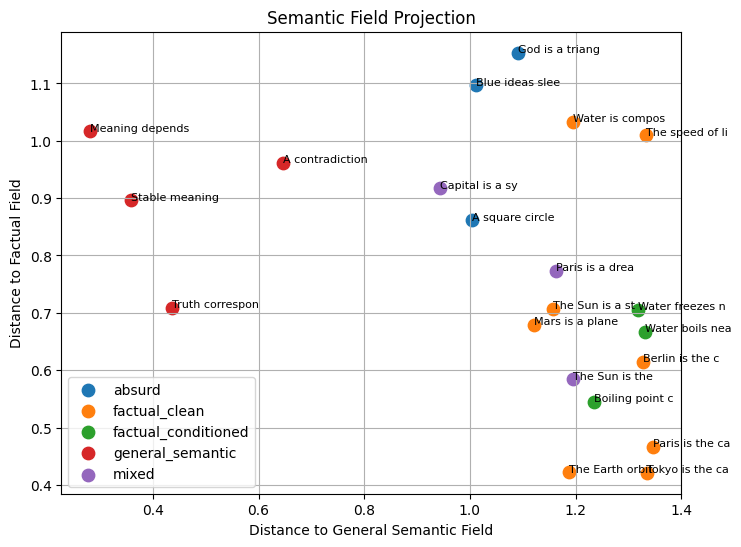

In [99]:
plt.figure(figsize=(8,6))

for group in df["group"].unique():
    subset = df[df["group"] == group]
    plt.scatter(
        subset["general_cost"],
        subset["factual_cost"],
        label=group,
        s=80
    )

for _, row in df.iterrows():
    plt.text(
        row["general_cost"],
        row["factual_cost"],
        row["sentence"][:15],
        fontsize=8
    )

plt.xlabel("Distance to General Semantic Field")
plt.ylabel("Distance to Factual Field")
plt.title("Semantic Field Projection")
plt.legend()
plt.grid(True)

plt.show()

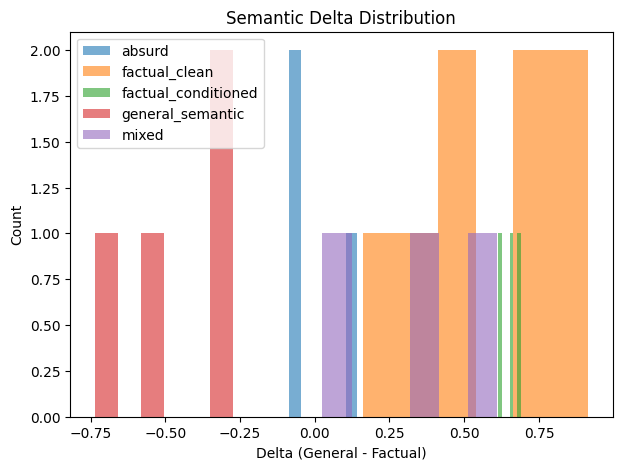

In [100]:
plt.figure(figsize=(7,5))

for group in df["group"].unique():
    subset = df[df["group"] == group]
    plt.hist(
        subset["delta_general_minus_factual"],
        bins=6,
        alpha=0.6,
        label=group
    )

plt.xlabel("Delta (General - Factual)")
plt.ylabel("Count")
plt.title("Semantic Delta Distribution")
plt.legend()

plt.show()

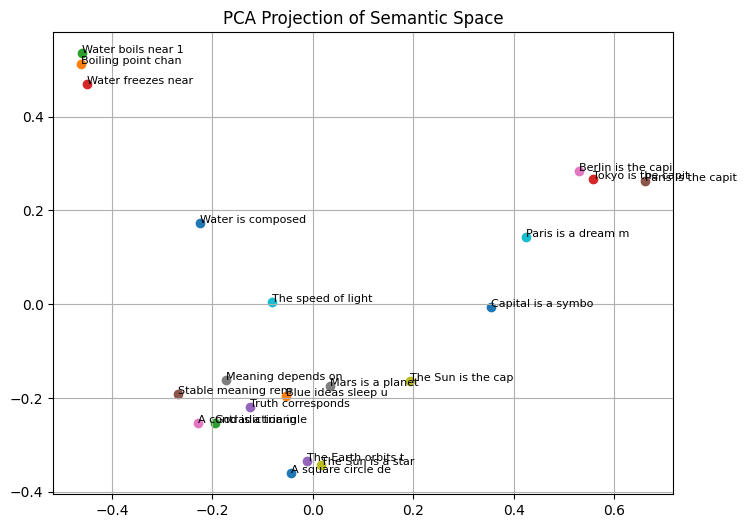

In [101]:
points = []
labels = []
groups = []

for _, row in df.iterrows():
    points.append(row["embedding"])
    labels.append(row["sentence"][:18])
    groups.append(row["group"])

X = np.array(points)

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.figure(figsize=(8,6))

for i in range(len(X2)):
    plt.scatter(X2[i,0], X2[i,1])
    plt.text(X2[i,0], X2[i,1], labels[i], fontsize=8)

plt.title("PCA Projection of Semantic Space")
plt.grid(True)

plt.show()

In [102]:
def classify(delta):
    if delta > 0.5:
        return "factual"
    if delta < -0.3:
        return "conceptual"
    if abs(delta) < 0.1:
        return "noise"
    return "mixed"

df["classification"] = df["delta_general_minus_factual"].apply(classify)

df[["sentence","group","classification","delta_general_minus_factual"]]

,sentence,group,classification,delta_general_minus_factual
0,A square circle defines the universe,absurd,mixed,0.142014
1,Blue ideas sleep under justice,absurd,noise,-0.084696
2,God is a triangle of silence in the database,absurd,noise,-0.062800
3,Tokyo is the capital of Japan,factual_clean,factual,0.913612
4,The Earth orbits the Sun,factual_clean,factual,0.765293
5,Paris is the capital of France,factual_clean,factual,0.880436
6,Berlin is the capital of Germany,factual_clean,factual,0.712043
7,Mars is a planet,factual_clean,mixed,0.441225
8,The Sun is a star,factual_clean,mixed,0.449613
9,The speed of light is about 300000 km/s,factual_clean,mixed,0.324372


In [103]:
def semantic_energy(v, general, factual, wg=1.0, wf=1.0):

    Og = projection_cost(v, general["basis"], general["mean_vector"])
    Of = projection_cost(v, factual["basis"], factual["mean_vector"])

    energy = wg*Og + wf*Of

    return Og, Of, energy

In [104]:
energies = []

for _, row in df.iterrows():

    Og, Of, E = semantic_energy(
        row["embedding"],
        general,
        factual
    )

    energies.append({
        "sentence": row["sentence"],
        "group": row["group"],
        "Og": Og,
        "Of": Of,
        "Energy": E
    })

energy_df = pd.DataFrame(energies)

energy_df

,sentence,group,Og,Of,Energy
0,A square circle defines the universe,absurd,1.003262,0.861249,1.864511
1,Blue ideas sleep under justice,absurd,1.011728,1.096424,2.108152
2,God is a triangle of silence in the database,absurd,1.090688,1.153488,2.244176
3,Tokyo is the capital of Japan,factual_clean,1.334763,0.421152,1.755915
4,The Earth orbits the Sun,factual_clean,1.186989,0.421696,1.608686
5,Paris is the capital of France,factual_clean,1.347019,0.466583,1.813601
6,Berlin is the capital of Germany,factual_clean,1.326980,0.614936,1.941916
7,Mars is a planet,factual_clean,1.120648,0.679423,1.800071
8,The Sun is a star,factual_clean,1.156943,0.707330,1.864272
9,The speed of light is about 300000 km/s,factual_clean,1.333701,1.009329,2.343030


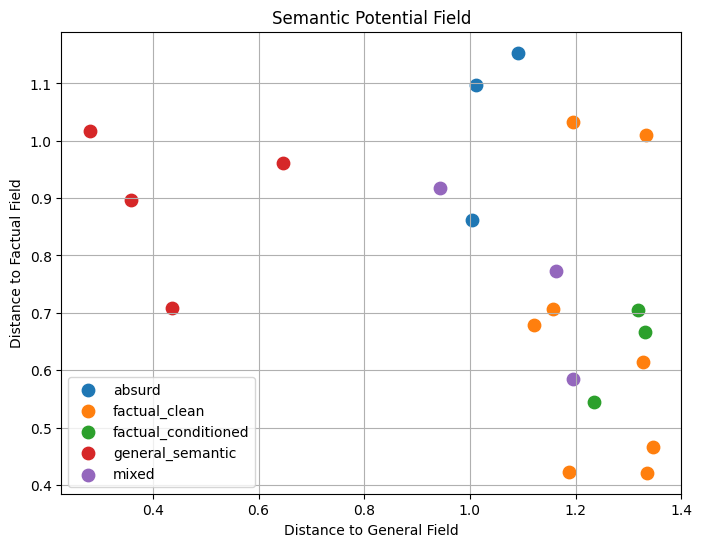

In [105]:
plt.figure(figsize=(8,6))

for group in energy_df["group"].unique():

    subset = energy_df[energy_df["group"] == group]

    plt.scatter(
        subset["Og"],
        subset["Of"],
        label=group,
        s=80
    )

plt.xlabel("Distance to General Field")
plt.ylabel("Distance to Factual Field")
plt.title("Semantic Potential Field")

plt.legend()
plt.grid(True)

plt.show()

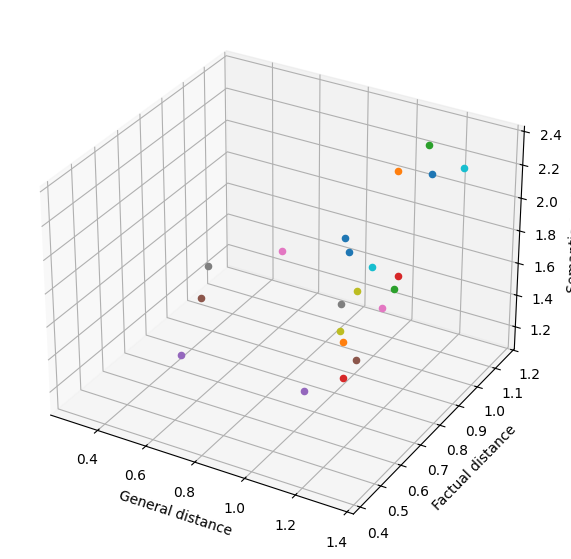

In [106]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

for _, row in energy_df.iterrows():

    ax.scatter(
        row["Og"],
        row["Of"],
        row["Energy"]
    )

ax.set_xlabel("General distance")
ax.set_ylabel("Factual distance")
ax.set_zlabel("Semantic energy")

plt.show()

In [107]:
TEST_BATTERIES = {}

TEST_BATTERIES["common"] = {

    "factual_clean": [
        "Paris is the capital of France",
        "Tokyo is the capital of Japan",
        "Berlin is the capital of Germany",
        "The Earth orbits the Sun",
        "The Moon orbits the Earth",
        "The Sun is a star",
        "Mars is a planet",
        "Water is composed of hydrogen and oxygen",
        "The Pacific Ocean is the largest ocean on Earth",
        "A week has seven days",
        "A year has twelve months",
        "100 centimeters make one meter",
        "The human heart pumps blood",
        "Electricity can power a light bulb",
        "The internet connects computers through networks"
    ],

    "factual_conditioned": [
        "Water boils near 100 degrees Celsius at sea level",
        "Water freezes near 0 degrees Celsius under standard pressure",
        "Boiling point changes with atmospheric pressure",
        "At higher altitude water boils at a lower temperature",
        "Battery life decreases under intensive use",
        "Sound travels faster in water than in air under normal conditions",
        "A car uses more fuel in stop and go traffic",
        "The value of a measurement depends on the units used"
    ],

    "conceptual_general": [
        "Meaning depends on context",
        "Truth corresponds to reality",
        "A contradiction invalidates a definition",
        "Stable meaning remains consistent across expressions",
        "Reference connects language to objects",
        "Coherence reduces semantic confusion",
        "Interpretation changes across domains",
        "A valid inference preserves logical structure"
    ],

    "mixed": [
        "Paris is a dream made of geography",
        "The internet is a river of memory",
        "Truth is a machine made of light",
        "Context is the gravity of meaning",
        "Measurement is the shadow of certainty"
    ],

    "absurd": [
        "Blue ideas sleep under justice",
        "A square circle defines the universe",
        "God is a triangle of silence in the database",
        "Gravity sings inside a password",
        "The refrigerator argues with tomorrow"
    ]
}

battery = TEST_BATTERIES["common"]

rows = []

for group, sentences in battery.items():
    for sentence in sentences:

        v = embed(sentence)

        g_cost = projection_cost(v, general["basis"], general["mean_vector"])
        f_cost = projection_cost(v, factual["basis"], factual["mean_vector"])

        g_top = top_invariants(v, general["C_norm"], general["labels"], top_k=3)
        f_top = top_invariants(v, factual["C_norm"], factual["labels"], top_k=3)

        rows.append({
            "group": group,
            "sentence": sentence,
            "embedding": v,
            "general_cost": g_cost,
            "factual_cost": f_cost,
            "delta_general_minus_factual": g_cost - f_cost,
            "top_general": g_top[0][0],
            "top_general_score": g_top[0][1],
            "top_factual": f_top[0][0],
            "top_factual_score": f_top[0][1],
        })

df = pd.DataFrame(rows)
df

,group,sentence,embedding,general_cost,factual_cost,delta_general_minus_factual,top_general,top_general_score,top_factual,top_factual_score
0,factual_clean,Paris is the capital of France,"[0.021429337563018316, 0.012553867625058807, -...",1.346886,0.466609,0.880276,Meaning,0.113648,NamedEntityFacts,0.746075
1,factual_clean,Tokyo is the capital of Japan,"[0.008905807579800999, -0.006963624178721861, ...",1.334763,0.421152,0.913612,Truth,0.142937,NamedEntityFacts,0.773641
2,factual_clean,Berlin is the capital of Germany,"[0.010073324572630578, 0.034890333292475005, 0...",1.326980,0.614936,0.712043,Reference,0.129038,NamedEntityFacts,0.645899
3,factual_clean,The Earth orbits the Sun,"[-0.020134969604360096, 0.006051931204946869, ...",1.186989,0.421696,0.765293,Relation,0.215406,Astronomy,0.756224
4,factual_clean,The Moon orbits the Earth,"[-0.021535601044179984, 0.012721419893922052, ...",1.205828,0.500553,0.705275,Truth,0.200996,Astronomy,0.705073
5,factual_clean,The Sun is a star,"[-0.020058372461296485, 0.0019619833899880306,...",1.156943,0.707330,0.449613,Relation,0.226073,Astronomy,0.592746
6,factual_clean,Mars is a planet,"[-0.014815914079084003, 0.017730269989593834, ...",1.120648,0.679423,0.441225,Reality,0.247810,Astronomy,0.562975
7,factual_clean,Water is composed of hydrogen and oxygen,"[0.024934214892417594, 0.04190290948260631, -0...",1.195947,1.033058,0.162889,Coherence,0.223251,ScientificRegularity,0.316861
8,factual_clean,The Pacific Ocean is the largest ocean on Earth,"[0.038759806223525754, 0.023133805604277573, 0...",1.302484,0.842026,0.460457,Reality,0.169972,NamedEntityFacts,0.457469
9,factual_clean,A week has seven days,"[-0.05526064399611667, -0.006068448688419494, ...",1.122482,1.026110,0.096373,Reality,0.230534,Astronomy,0.258806


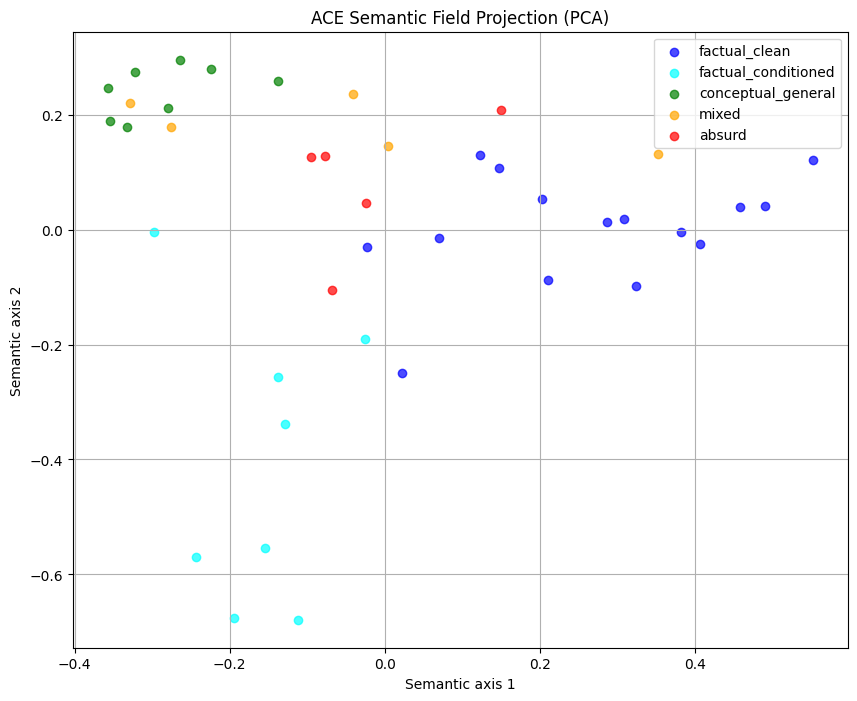

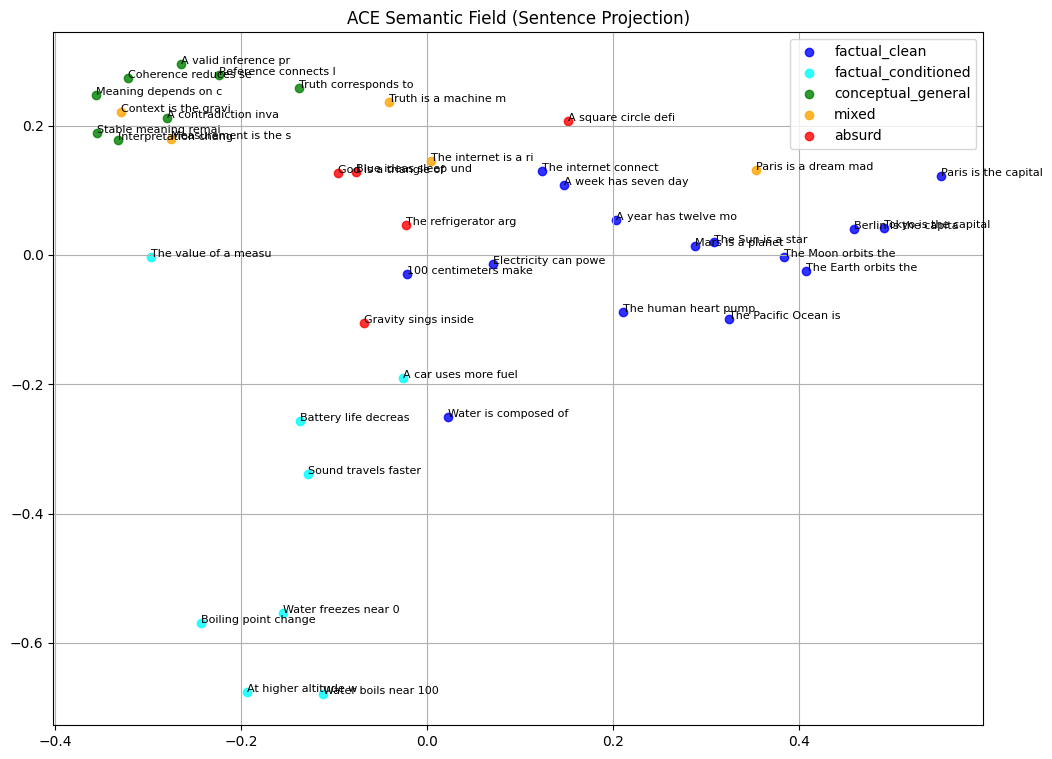

In [108]:
# --- PROYECCION 2D DEL CAMPO SEMANTICO ---

X = np.vstack(df["embedding"].values)

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

df["x"] = X2[:,0]
df["y"] = X2[:,1]

df.head()

plt.figure(figsize=(10,8))

colors = {
    "factual_clean": "blue",
    "factual_conditioned": "cyan",
    "conceptual_general": "green",
    "mixed": "orange",
    "absurd": "red"
}

for group in df["group"].unique():

    subset = df[df["group"] == group]

    plt.scatter(
        subset["x"],
        subset["y"],
        label=group,
        alpha=0.7,
        color=colors.get(group, "gray")
    )

plt.title("ACE Semantic Field Projection (PCA)")
plt.xlabel("Semantic axis 1")
plt.ylabel("Semantic axis 2")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(12,9))

for group in df["group"].unique():

    subset = df[df["group"] == group]

    plt.scatter(
        subset["x"],
        subset["y"],
        label=group,
        alpha=0.8,
        color=colors.get(group, "gray")
    )

    for _, row in subset.iterrows():
        plt.text(
            row["x"],
            row["y"],
            row["sentence"][:20],
            fontsize=8
        )

plt.title("ACE Semantic Field (Sentence Projection)")
plt.legend()
plt.grid(True)
plt.show()

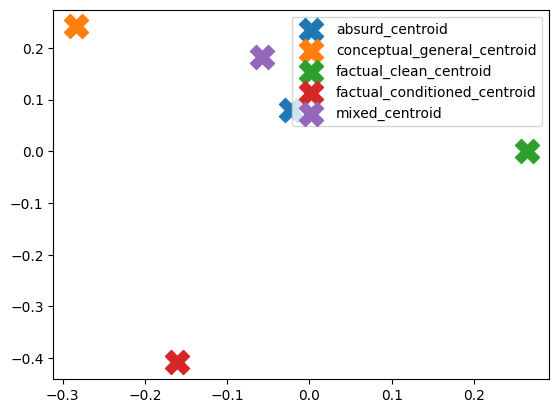

In [109]:
centroids = df.groupby("group")[["x","y"]].mean()
centroids

for group, row in centroids.iterrows():
    plt.scatter(row["x"], row["y"], s=300, marker="X", label=f"{group}_centroid")

plt.legend()

In [110]:
PARAPHRASE_TESTS = {
    "factual_clean": [
        "Paris is the capital of France",
        "France's capital is Paris",
        "The capital city of France is Paris",
    ],
    "factual_conditioned": [
        "Water boils near 100 degrees Celsius at sea level",
        "At sea level, water boils at about 100°C",
        "The boiling point of water is near 100°C under sea-level conditions",
    ],
    "conceptual_general": [
        "Meaning depends on context",
        "Context determines meaning",
        "The meaning of an expression changes with context",
    ],
}

In [111]:
MULTILINGUAL_TESTS = {
    "factual_clean": [
        "Paris is the capital of France",
        "París es la capital de Francia",
        "Paris est la capitale de la France",
    ],
    "factual_conditioned": [
        "Water boils near 100 degrees Celsius at sea level",
        "El agua hierve cerca de 100 grados Celsius al nivel del mar",
        "L'eau bout près de 100 degrés Celsius au niveau de la mer",
    ],
    "conceptual_general": [
        "Meaning depends on context",
        "El significado depende del contexto",
        "Le sens dépend du contexte",
    ],
}

In [112]:
def run_equivalence_tests(test_dict, label="test"):
    rows = []

    for group, sentences in test_dict.items():
        for sentence in sentences:
            v = embed(sentence)

            g_cost = projection_cost(v, general["basis"], general["mean_vector"])
            f_cost = projection_cost(v, factual["basis"], factual["mean_vector"])

            rows.append({
                "test_label": label,
                "group": group,
                "sentence": sentence,
                "embedding": v,
                "general_cost": g_cost,
                "factual_cost": f_cost,
                "delta": g_cost - f_cost,
            })

    out = pd.DataFrame(rows)
    return out

In [113]:
df_para = run_equivalence_tests(PARAPHRASE_TESTS, label="paraphrase")
df_multi = run_equivalence_tests(MULTILINGUAL_TESTS, label="multilingual")

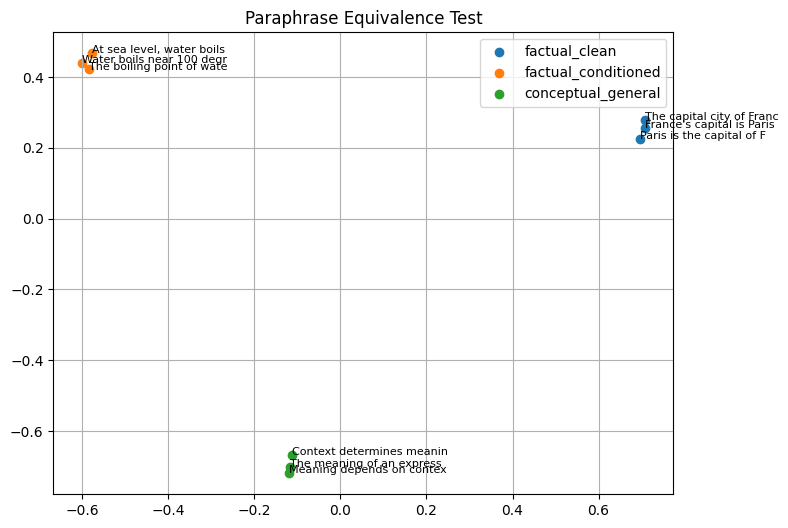

In [114]:
X_para = np.vstack(df_para["embedding"].values)
X2_para = PCA(n_components=2).fit_transform(X_para)
df_para["x"] = X2_para[:, 0]
df_para["y"] = X2_para[:, 1]

plt.figure(figsize=(8,6))
for group in df_para["group"].unique():
    subset = df_para[df_para["group"] == group]
    plt.scatter(subset["x"], subset["y"], label=group)

for _, row in df_para.iterrows():
    plt.text(row["x"], row["y"], row["sentence"][:25], fontsize=8)

plt.title("Paraphrase Equivalence Test")
plt.legend()
plt.grid(True)
plt.show()

In [115]:
MEANING_PROTOTYPES = {
    "capital_relation": [
        "Paris is the capital of France",
        "France's capital is Paris",
        "The capital city of France is Paris",
        "Tokyo is the capital of Japan",
        "Japan's capital is Tokyo",
        "Berlin is the capital of Germany",
        "París es la capital de Francia",
        "Tokio es la capital de Japón"
    ],

    "orbit_relation": [
        "The Earth orbits the Sun",
        "The Moon orbits the Earth",
        "Mars orbits the Sun",
        "The Earth revolves around the Sun",
        "La Tierra gira alrededor del Sol",
        "La Luna orbita la Tierra"
    ],

    "composition_relation": [
        "Water is composed of hydrogen and oxygen",
        "Water consists of hydrogen and oxygen",
        "H2O is made of hydrogen and oxygen",
        "El agua está compuesta de hidrógeno y oxígeno"
    ],

    "measurement_relation": [
        "100 centimeters make one meter",
        "One meter equals one hundred centimeters",
        "Temperature can be measured in degrees Celsius",
        "Distance can be measured in meters",
        "La temperatura puede medirse en grados Celsius"
    ],

    "boiling_relation": [
        "Water boils near 100 degrees Celsius at sea level",
        "At sea level, water boils at about 100°C",
        "El agua hierve cerca de 100 grados Celsius al nivel del mar"
    ],

    "freezing_relation": [
        "Water freezes near 0 degrees Celsius under standard pressure",
        "Under standard pressure, water freezes near 0°C",
        "El agua se congela cerca de 0 grados Celsius bajo presión estándar"
    ],

    "pressure_dependence": [
        "Boiling point changes with atmospheric pressure",
        "Pressure affects boiling point",
        "At higher altitude water boils at a lower temperature",
        "La presión afecta el punto de ebullición"
    ],

    "operational_dependence": [
        "Battery life decreases under intensive use",
        "A car uses more fuel in stop and go traffic",
        "Completion time depends on workload and constraints",
        "Network latency depends on routing and congestion"
    ],

    "meaning_context_relation": [
        "Meaning depends on context",
        "Context determines meaning",
        "The meaning of an expression changes with context",
        "El significado depende del contexto",
        "Le sens dépend du contexte"
    ],

    "truth_reality_relation": [
        "Truth corresponds to reality",
        "A statement is true when it matches the facts",
        "La verdad corresponde con la realidad",
        "A true proposition reflects what is the case"
    ],

    "contradiction_invalidates": [
        "A contradiction invalidates a definition",
        "Contradiction breaks logical validity",
        "Una contradicción invalida una definición",
        "A self-contradictory statement cannot remain fully coherent"
    ],

    "coherence_stability_relation": [
        "Stable meaning remains consistent across expressions",
        "Coherence reduces semantic confusion",
        "A coherent explanation preserves structure",
        "La coherencia mantiene la estabilidad del significado"
    ],
}

In [116]:
def build_meaning_matrix(prototypes):
    rows = []
    labels = []

    for label, sentences in prototypes.items():
        vectors = [embed(s) for s in sentences]
        centroid = np.mean(np.vstack(vectors), axis=0)
        rows.append(centroid)
        labels.append(label)

    M = np.vstack(rows)
    return M, labels

In [117]:
MEANING_MATRIX, MEANING_LABELS = build_meaning_matrix(MEANING_PROTOTYPES)

print("Meaning Matrix shape:", MEANING_MATRIX.shape)
print("Meaning labels:", MEANING_LABELS)

Meaning Matrix shape: (12, 1536)
Meaning labels: ['capital_relation', 'orbit_relation', 'composition_relation', 'measurement_relation', 'boiling_relation', 'freezing_relation', 'pressure_dependence', 'operational_dependence', 'meaning_context_relation', 'truth_reality_relation', 'contradiction_invalidates', 'coherence_stability_relation']


In [118]:
meaning_pca = PCA(n_components=2)
M2 = meaning_pca.fit_transform(MEANING_MATRIX)

meaning_df = pd.DataFrame({
    "label": MEANING_LABELS,
    "x": M2[:, 0],
    "y": M2[:, 1],
})

meaning_df

,label,x,y
0,capital_relation,0.141409,0.568087
1,orbit_relation,0.062960,0.433970
2,composition_relation,-0.182679,0.187986
3,measurement_relation,-0.100556,0.060343
4,boiling_relation,-0.572415,-0.088697
5,freezing_relation,-0.524541,-0.194077
6,pressure_dependence,-0.388134,-0.200068
7,operational_dependence,0.092698,0.027442
8,meaning_context_relation,0.385181,-0.215463
9,truth_reality_relation,0.321646,-0.074383


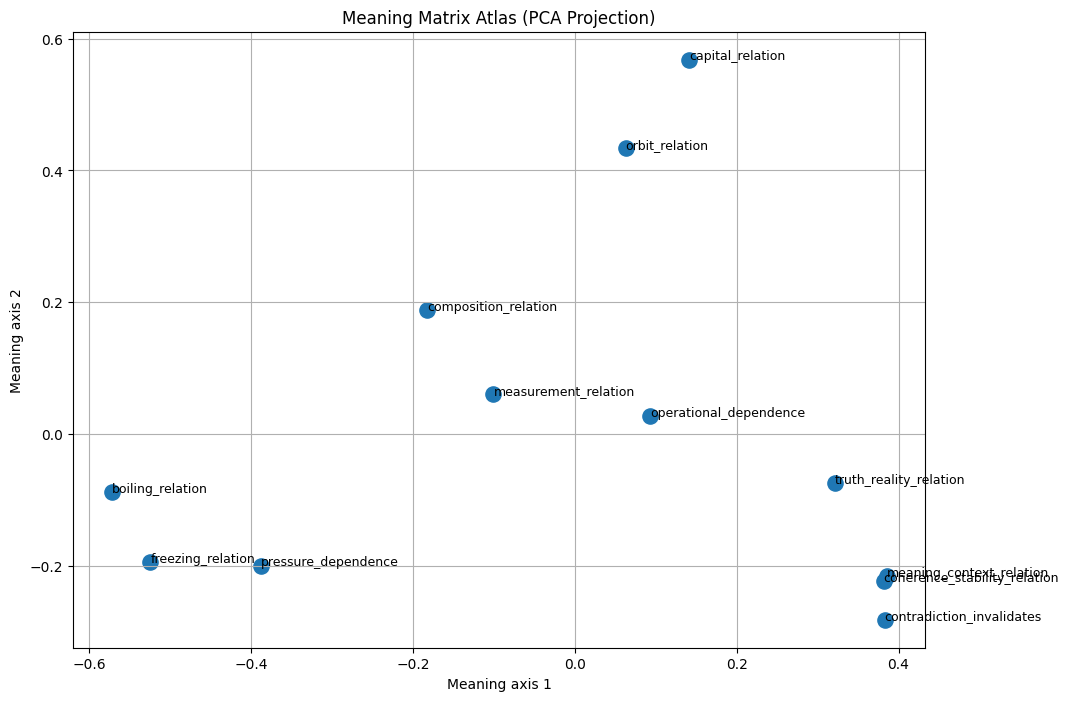

In [119]:
plt.figure(figsize=(11, 8))

plt.scatter(meaning_df["x"], meaning_df["y"], s=120)

for _, row in meaning_df.iterrows():
    plt.text(row["x"], row["y"], row["label"], fontsize=9)

plt.title("Meaning Matrix Atlas (PCA Projection)")
plt.xlabel("Meaning axis 1")
plt.ylabel("Meaning axis 2")
plt.grid(True)
plt.show()

In [120]:
def nearest_meaning_node(sentence, meaning_matrix, meaning_labels, top_k=3):
    v = embed(sentence)
    scores = []

    for i, label in enumerate(meaning_labels):
        score = float(np.dot(v, meaning_matrix[i]))
        scores.append((label, score))

    scores.sort(key=lambda x: x[1], reverse=True)
    return scores[:top_k]

In [121]:
TEST_MEANING_SENTENCES = [
    "France's capital is Paris",
    "The Earth revolves around the Sun",
    "Water is made of hydrogen and oxygen",
    "Pressure changes the boiling point of water",
    "Context determines the meaning of a sentence",
    "Truth matches reality",
    "A contradiction destroys coherence",
]

for s in TEST_MEANING_SENTENCES:
    print("\nSentence:", s)
    for label, score in nearest_meaning_node(s, MEANING_MATRIX, MEANING_LABELS):
        print(f"  {label:<30} score={score:.4f}")


Sentence: France's capital is Paris
  capital_relation               score=0.6644
  orbit_relation                 score=0.1131
  truth_reality_relation         score=0.0972

Sentence: The Earth revolves around the Sun
  orbit_relation                 score=0.7138
  truth_reality_relation         score=0.1870
  composition_relation           score=0.1771

Sentence: Water is made of hydrogen and oxygen
  composition_relation           score=0.8135
  freezing_relation              score=0.2847
  boiling_relation               score=0.2674

Sentence: Pressure changes the boiling point of water
  pressure_dependence            score=0.6840
  boiling_relation               score=0.4517
  freezing_relation              score=0.4205

Sentence: Context determines the meaning of a sentence
  meaning_context_relation       score=0.6402
  coherence_stability_relation   score=0.3527
  contradiction_invalidates      score=0.2561

Sentence: Truth matches reality
  truth_reality_relation         sco

In [122]:
# Similaridad nodo a nodo
similarity_matrix = MEANING_MATRIX @ MEANING_MATRIX.T

meaning_sim_df = pd.DataFrame(
    similarity_matrix,
    index=MEANING_LABELS,
    columns=MEANING_LABELS
)

meaning_sim_df.round(3)

,capital_relation,orbit_relation,composition_relation,measurement_relation,boiling_relation,freezing_relation,pressure_dependence,operational_dependence,meaning_context_relation,truth_reality_relation,contradiction_invalidates,coherence_stability_relation
capital_relation,0.646,0.107,0.084,0.067,0.036,0.019,0.022,0.021,0.049,0.095,0.047,0.051
orbit_relation,0.107,0.709,0.162,0.093,0.142,0.102,0.099,0.071,0.078,0.160,0.110,0.106
composition_relation,0.084,0.162,0.791,0.130,0.244,0.277,0.193,0.034,0.056,0.142,0.126,0.151
measurement_relation,0.067,0.093,0.130,0.535,0.244,0.218,0.138,0.088,0.111,0.126,0.093,0.094
boiling_relation,0.036,0.142,0.244,0.244,0.830,0.455,0.465,0.061,0.044,0.087,0.072,0.043
freezing_relation,0.019,0.102,0.277,0.218,0.455,0.860,0.409,0.076,0.054,0.105,0.123,0.096
pressure_dependence,0.022,0.099,0.193,0.138,0.465,0.409,0.679,0.120,0.106,0.107,0.126,0.127
operational_dependence,0.021,0.071,0.034,0.088,0.061,0.076,0.120,0.444,0.122,0.060,0.100,0.110
meaning_context_relation,0.049,0.078,0.056,0.111,0.044,0.054,0.106,0.122,0.692,0.218,0.256,0.311
truth_reality_relation,0.095,0.160,0.142,0.126,0.087,0.105,0.107,0.060,0.218,0.634,0.331,0.301


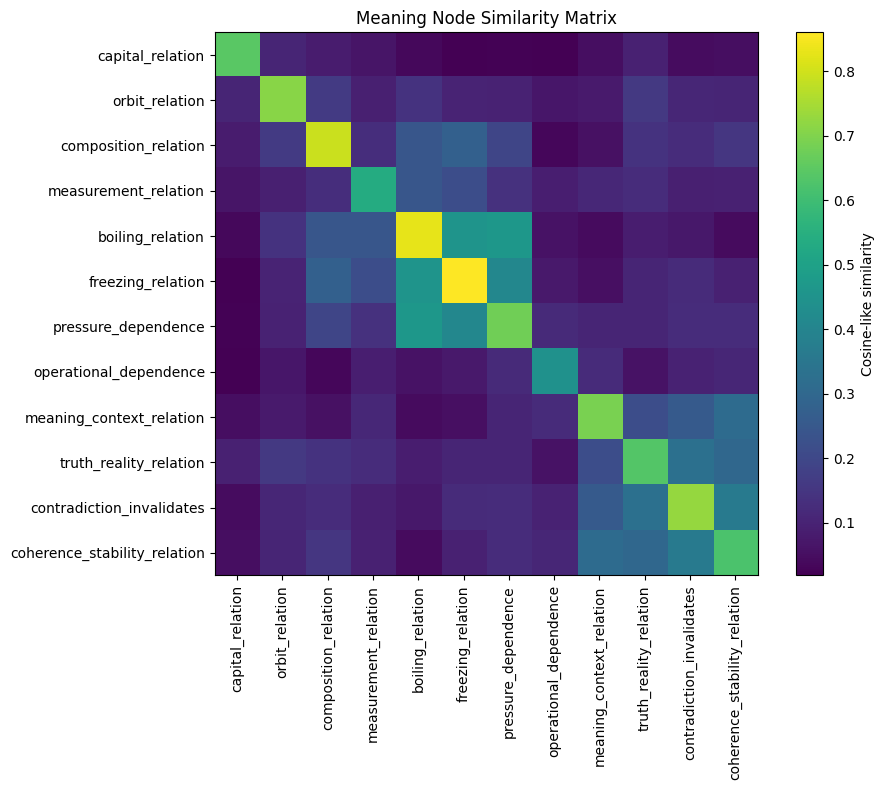

In [123]:
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, cmap="viridis")
plt.colorbar(label="Cosine-like similarity")
plt.xticks(range(len(MEANING_LABELS)), MEANING_LABELS, rotation=90)
plt.yticks(range(len(MEANING_LABELS)), MEANING_LABELS)
plt.title("Meaning Node Similarity Matrix")
plt.tight_layout()
plt.show()

In [124]:
import networkx as nx

threshold = 0.30
G = nx.Graph()

for label in MEANING_LABELS:
    G.add_node(label)

for i, a in enumerate(MEANING_LABELS):
    for j, b in enumerate(MEANING_LABELS):
        if j <= i:
            continue
        sim = similarity_matrix[i][j]

        if sim > threshold:
            G.add_edge(a, b, weight=sim)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 12
Edges: 7


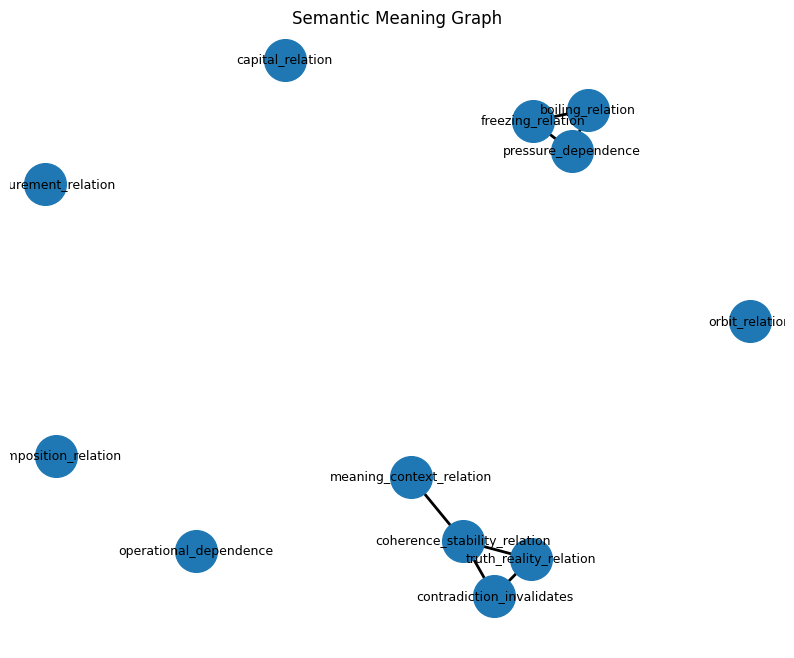

In [125]:
plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, pos, node_size=900)
nx.draw_networkx_edges(G, pos, width=2)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("Semantic Meaning Graph")
plt.axis("off")
plt.show()

In [126]:
# Proyección 2D de la Meaning Matrix
meaning_pca = PCA(n_components=2)
M2 = meaning_pca.fit_transform(MEANING_MATRIX)

meaning_df = pd.DataFrame({
    "label": MEANING_LABELS,
    "x": M2[:, 0],
    "y": M2[:, 1],
})

meaning_df

,label,x,y
0,capital_relation,0.141409,0.568087
1,orbit_relation,0.062960,0.433970
2,composition_relation,-0.182679,0.187986
3,measurement_relation,-0.100556,0.060343
4,boiling_relation,-0.572415,-0.088697
5,freezing_relation,-0.524541,-0.194077
6,pressure_dependence,-0.388134,-0.200068
7,operational_dependence,0.092698,0.027442
8,meaning_context_relation,0.385181,-0.215463
9,truth_reality_relation,0.321646,-0.074383


In [127]:
import numpy as np
import matplotlib.pyplot as plt

# coordenadas de nodos
node_xy = meaning_df[["x", "y"]].values

# malla del plano
xmin, xmax = meaning_df["x"].min() - 0.4, meaning_df["x"].max() + 0.4
ymin, ymax = meaning_df["y"].min() - 0.4, meaning_df["y"].max() + 0.4

xx, yy = np.meshgrid(
    np.linspace(xmin, xmax, 250),
    np.linspace(ymin, ymax, 250)
)

grid = np.stack([xx, yy], axis=-1)

# ancho del kernel
sigma = 0.18

# potencial semántico
potential = np.zeros(xx.shape)

for mu in node_xy:
    dx = grid[..., 0] - mu[0]
    dy = grid[..., 1] - mu[1]
    d2 = dx**2 + dy**2
    potential += np.exp(-d2 / (2 * sigma**2))

# energía (opcional)
energy = 1.0 / (potential + 1e-6)

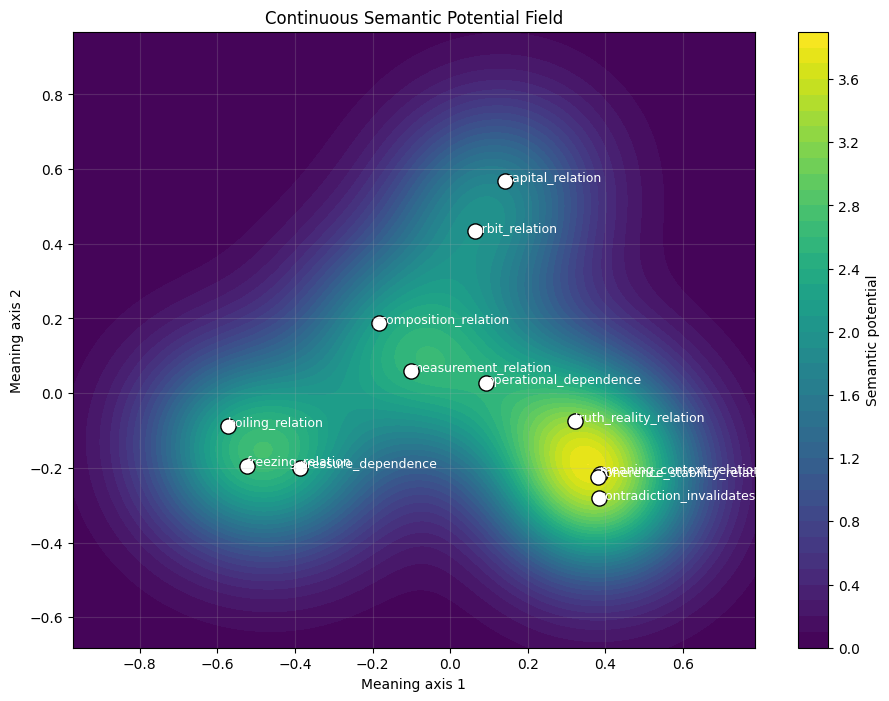

In [128]:
plt.figure(figsize=(11, 8))

# puedes usar potential o energy
cont = plt.contourf(xx, yy, potential, levels=40, cmap="viridis")
plt.colorbar(cont, label="Semantic potential")

# nodos
plt.scatter(meaning_df["x"], meaning_df["y"], color="white", s=120, edgecolor="black")

for _, row in meaning_df.iterrows():
    plt.text(row["x"], row["y"], row["label"], fontsize=9, color="white")

plt.title("Continuous Semantic Potential Field")
plt.xlabel("Meaning axis 1")
plt.ylabel("Meaning axis 2")
plt.grid(True, alpha=0.2)
plt.show()

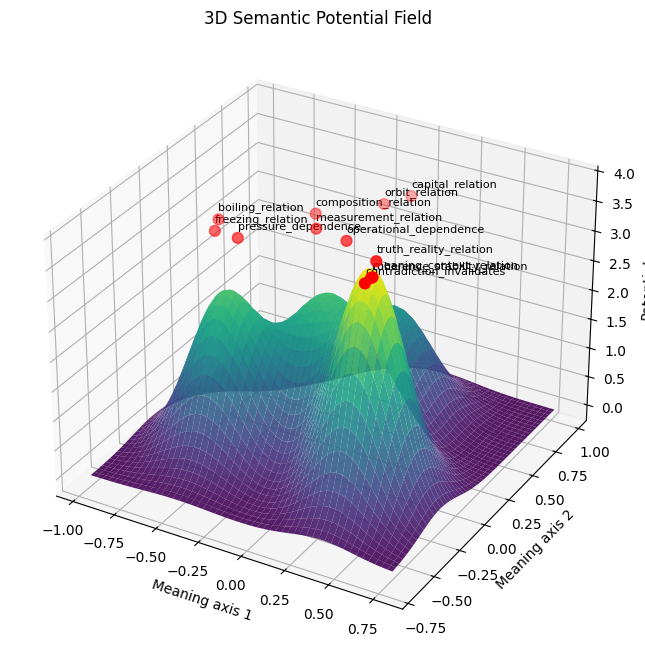

In [129]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(xx, yy, potential, cmap="viridis", linewidth=0, antialiased=True, alpha=0.9)

# nodos
ax.scatter(
    meaning_df["x"],
    meaning_df["y"],
    np.max(potential) * np.ones(len(meaning_df)) * 0.98,
    color="red",
    s=60
)

for _, row in meaning_df.iterrows():
    ax.text(row["x"], row["y"], np.max(potential) * 1.02, row["label"], fontsize=8)

ax.set_title("3D Semantic Potential Field")
ax.set_xlabel("Meaning axis 1")
ax.set_ylabel("Meaning axis 2")
ax.set_zlabel("Potential")
plt.show()

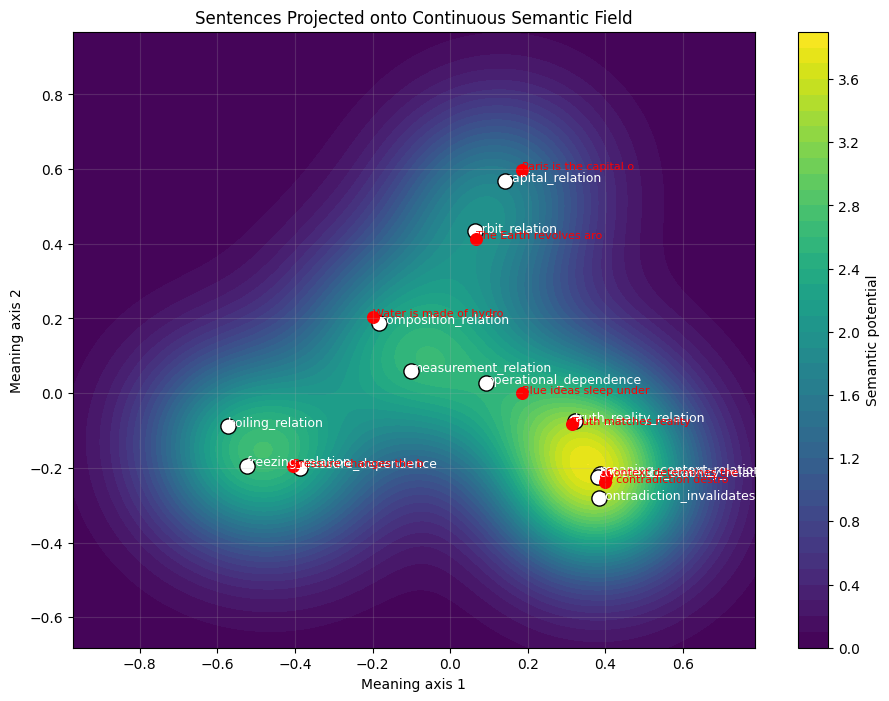

In [130]:
def project_sentences_to_meaning_plane(sentences, pca_model):
    vecs = np.vstack([embed(s) for s in sentences])
    return pca_model.transform(vecs)

TEST_SENTENCES = [
    "Paris is the capital of France",
    "The Earth revolves around the Sun",
    "Water is made of hydrogen and oxygen",
    "Pressure changes the boiling point of water",
    "Context determines the meaning of a sentence",
    "Truth matches reality",
    "A contradiction destroys coherence",
    "Blue ideas sleep under justice",
]

S2 = project_sentences_to_meaning_plane(TEST_SENTENCES, meaning_pca)

plt.figure(figsize=(11, 8))
cont = plt.contourf(xx, yy, potential, levels=40, cmap="viridis")
plt.colorbar(cont, label="Semantic potential")

plt.scatter(meaning_df["x"], meaning_df["y"], color="white", s=120, edgecolor="black")
for _, row in meaning_df.iterrows():
    plt.text(row["x"], row["y"], row["label"], fontsize=9, color="white")

plt.scatter(S2[:, 0], S2[:, 1], color="red", s=70)

for i, s in enumerate(TEST_SENTENCES):
    plt.text(S2[i, 0], S2[i, 1], s[:22], fontsize=8, color="red")

plt.title("Sentences Projected onto Continuous Semantic Field")
plt.xlabel("Meaning axis 1")
plt.ylabel("Meaning axis 2")
plt.grid(True, alpha=0.2)
plt.show()

In [131]:
!ls dataset

ace_benchmark_small.json


In [132]:
import json

with open("dataset/ace_benchmark_small.json","r") as f:
    dataset = json.load(f)

print(len(dataset), "prompts loaded")

9 prompts loaded


In [134]:
def origin_cost(v):
    return projection_cost(v, general["basis"], general["mean_vector"])

In [135]:
results = []

for item in dataset:

    prompt = item["prompt"]

    for r in item["responses"]:

        text = r["text"]
        label = r["label"]

        v = embed(text)

        cost = origin_cost(v)   # tu función ACE

        results.append({
            "prompt": prompt,
            "response": text,
            "label": label,
            "origin_cost": float(cost)
        })

print("processed:", len(results), "responses")

processed: 27 responses


In [138]:
import pandas as pd

df_bench = pd.DataFrame(results)
df_bench.head()

,prompt,response,label,origin_cost
0,What is the capital of France?,Paris is the capital of France.,correct,1.394433
1,What is the capital of France?,France's capital city is Paris.,correct,1.456338
2,What is the capital of France?,The capital of France is Berlin.,hallucination,1.426354
3,What planet orbits the Sun?,The Earth orbits the Sun.,correct,1.258155
4,What planet orbits the Sun?,Earth revolves around the Sun.,correct,1.217900


In [139]:
df_bench.groupby("label")["origin_cost"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
correct,18.0,1.175707,0.313484,0.350476,1.075978,1.316651,1.360622,1.456338
hallucination,7.0,1.250008,0.201871,0.815397,1.257431,1.281170,1.356136,1.426354
nonsense,2.0,1.267235,0.047890,1.233372,1.250304,1.267235,1.284167,1.301098


In [140]:
df_bench.groupby("label")["origin_cost"].mean().sort_values()

,origin_cost
label,
correct,1.175707
hallucination,1.250008
nonsense,1.267235


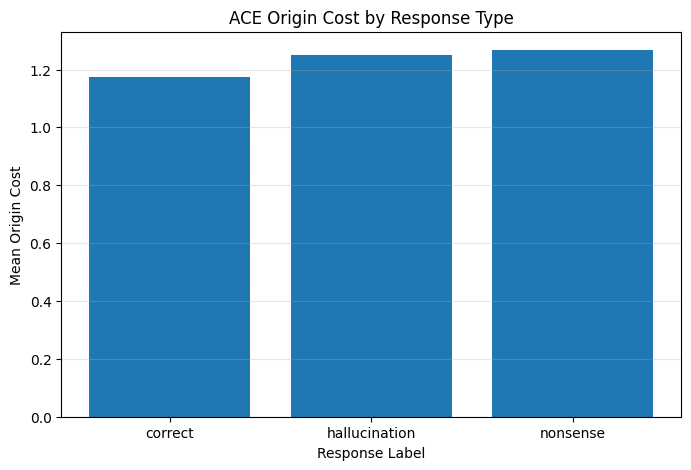

In [141]:
import matplotlib.pyplot as plt

plot_data = df_bench.groupby("label")["origin_cost"].mean().sort_values()

plt.figure(figsize=(8,5))
plt.bar(plot_data.index, plot_data.values)
plt.title("ACE Origin Cost by Response Type")
plt.ylabel("Mean Origin Cost")
plt.xlabel("Response Label")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# ACE Semantic Landscape Analyzer

Esta sección convierte el notebook de demo en una herramienta de **cartografía semántica**.

Objetivos:

- detectar **valles / attractors** mediante clustering
- estimar **densidad local** del campo
- identificar **regiones inestables** y frases frontera
- revelar **huecos del paisaje** como candidatos para nuevos nodos

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Construimos un atlas de frases a partir de los prototipos actuales
atlas_rows = []
for label, sentences in MEANING_PROTOTYPES.items():
    for sentence in sentences:
        atlas_rows.append({
            "group": label,
            "sentence": sentence,
            "embedding": embed(sentence)
        })

atlas_df = pd.DataFrame(atlas_rows)
atlas_X = np.vstack(atlas_df["embedding"].values)

# Proyección 2D para visualización cartográfica
landscape_pca = PCA(n_components=2)
atlas_2d = landscape_pca.fit_transform(atlas_X)

atlas_df["x"] = atlas_2d[:, 0]
atlas_df["y"] = atlas_2d[:, 1]

print("Atlas sentences:", len(atlas_df))
print("Prototype groups:", atlas_df["group"].nunique())
atlas_df.head()

In [ ]:
# 1) Detección de attractors / valles con DBSCAN
clusterer = DBSCAN(eps=0.20, min_samples=2, metric="cosine")
cluster_labels = clusterer.fit_predict(atlas_X)

atlas_df["cluster"] = cluster_labels
cluster_summary = (
    atlas_df.groupby("cluster")
    .agg(
        n=("sentence", "count"),
        groups=("group", lambda s: sorted(set(s)))
    )
    .reset_index()
    .sort_values(["cluster", "n"])
)

cluster_summary

In [ ]:
plt.figure(figsize=(11, 8))

unique_clusters = sorted(atlas_df["cluster"].unique())
for cl in unique_clusters:
    mask = atlas_df["cluster"] == cl
    label = f"cluster {cl}" if cl != -1 else "noise / frontier"
    plt.scatter(atlas_df.loc[mask, "x"], atlas_df.loc[mask, "y"], s=90, alpha=0.8, label=label)

for _, row in atlas_df.iterrows():
    plt.text(row["x"], row["y"], row["group"], fontsize=7, alpha=0.8)

plt.title("ACE Landscape — Attractors and Frontier Regions")
plt.xlabel("Landscape axis 1")
plt.ylabel("Landscape axis 2")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

In [ ]:
# 2) Densidad local del campo: mide regiones más pobladas / estables
kde = KernelDensity(kernel="gaussian", bandwidth=0.12).fit(atlas_X)
log_density = kde.score_samples(atlas_X)
atlas_df["log_density"] = log_density

density_summary = (
    atlas_df.groupby("group")["log_density"]
    .agg(["count", "mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

density_summary

In [ ]:
plt.figure(figsize=(11, 8))
sc = plt.scatter(
    atlas_df["x"], atlas_df["y"],
    c=atlas_df["log_density"],
    s=110
)
plt.colorbar(sc, label="Local semantic density (log)")
for _, row in atlas_df.iterrows():
    plt.text(row["x"], row["y"], row["group"], fontsize=7)
plt.title("ACE Landscape — Local Semantic Density")
plt.xlabel("Landscape axis 1")
plt.ylabel("Landscape axis 2")
plt.grid(True, alpha=0.25)
plt.show()

In [ ]:
# 3) Centroides de grupos y distancia al centro: estabilidad local
group_centroids = atlas_df.groupby("group")["embedding"].apply(
    lambda col: np.mean(np.vstack(col.values), axis=0)
).to_dict()

def cosine_distance(a, b):
    return 1.0 - float(np.dot(a, b))

atlas_df["distance_to_group_centroid"] = atlas_df.apply(
    lambda row: cosine_distance(row["embedding"], group_centroids[row["group"]]),
    axis=1
)

stability_summary = (
    atlas_df.groupby("group")["distance_to_group_centroid"]
    .agg(["count", "mean", "std", "max"])
    .sort_values("mean")
)

stability_summary

In [ ]:
# 4) Frases frontera del atlas actual: las más alejadas del centro de su región
frontier_df = atlas_df.sort_values(
    ["distance_to_group_centroid", "log_density"],
    ascending=[False, True]
)[["group", "sentence", "distance_to_group_centroid", "log_density", "cluster"]].head(20)

frontier_df

In [ ]:
# 5) Proyección de frases externas: benchmark como sonda cartográfica
probe_sentences = []
if "dataset" in globals():
    for item in dataset:
        for r in item["responses"]:
            probe_sentences.append({
                "label": r["label"],
                "sentence": r["text"],
                "embedding": embed(r["text"])
            })
else:
    probe_sentences = [
        {"label": "probe", "sentence": s, "embedding": embed(s)}
        for s in TEST_SENTENCES
    ]

probe_df = pd.DataFrame(probe_sentences).drop_duplicates(subset=["sentence"]).reset_index(drop=True)
probe_X = np.vstack(probe_df["embedding"].values)
probe_2d = landscape_pca.transform(probe_X)

probe_df["x"] = probe_2d[:, 0]
probe_df["y"] = probe_2d[:, 1]
probe_df["nearest_group"] = [
    max(
        [(g, float(np.dot(v, c))) for g, c in group_centroids.items()],
        key=lambda x: x[1]
    )[0]
    for v in probe_df["embedding"]
]
probe_df["nearest_similarity"] = [
    max(float(np.dot(v, c)) for c in group_centroids.values())
    for v in probe_df["embedding"]
]
probe_df["origin_cost"] = [origin_cost(v) for v in probe_df["embedding"]]
probe_df["log_density"] = kde.score_samples(probe_X)

probe_df.head()

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(atlas_df["x"], atlas_df["y"], s=80, alpha=0.30, label="atlas")
plt.scatter(probe_df["x"], probe_df["y"], s=80, alpha=0.85, marker="x", label="probes")

for _, row in probe_df.head(40).iterrows():
    plt.text(row["x"], row["y"], row["label"], fontsize=7)

plt.title("ACE Landscape — Benchmark as Cartographic Probe")
plt.xlabel("Landscape axis 1")
plt.ylabel("Landscape axis 2")
plt.grid(True, alpha=0.25)
plt.legend()
plt.show()

In [ ]:
# 6) Análisis de huecos: frases con alto costo o baja densidad
gap_df = probe_df.sort_values(
    ["origin_cost", "log_density", "nearest_similarity"],
    ascending=[False, True, True]
)[["label", "sentence", "nearest_group", "nearest_similarity", "origin_cost", "log_density"]]

gap_df.head(25)

In [ ]:
# 7) Resumen interpretativo automático
def landscape_diagnosis(row):
    notes = []
    if row["origin_cost"] > probe_df["origin_cost"].quantile(0.75):
        notes.append("high_origin_cost")
    if row["log_density"] < probe_df["log_density"].quantile(0.25):
        notes.append("low_density")
    if row["nearest_similarity"] < probe_df["nearest_similarity"].quantile(0.25):
        notes.append("weak_anchor")
    return ", ".join(notes) if notes else "well_absorbed"

probe_df["diagnosis"] = probe_df.apply(landscape_diagnosis, axis=1)

diagnosis_summary = (
    probe_df.groupby(["label", "diagnosis"])
    .size()
    .reset_index(name="count")
    .sort_values(["count"], ascending=False)
)

diagnosis_summary.head(20)

In [ ]:
# 8) Candidatos automáticos para expansión de la Meaning Matrix
candidate_gaps = probe_df[probe_df["diagnosis"] != "well_absorbed"].copy()

def suggest_missing_node(sentence, nearest_group):
    s = sentence.lower()
    if any(w in s for w in ["respire", "breath", "oxygen", "lungs", "photosynthesis"]):
        return "biological_function_relation"
    if any(w in s for w in ["star", "sun", "planet", "orbit", "solar"]):
        return "stellar_identity_relation"
    if any(w in s for w in ["centimeter", "meter", "kilometer", "convert", "degree"]):
        return "unit_conversion_relation"
    if any(w in s for w in ["calendar", "month", "day", "year", "week"]):
        return "calendar_relation"
    if any(w in s for w in ["network", "router", "ip", "internet", "server"]):
        return "network_relation"
    if any(w in s for w in ["electric", "voltage", "current", "switch", "battery"]):
        return "electrical_function_relation"
    return f"expand_or_refine::{nearest_group}"

candidate_gaps["suggested_node"] = candidate_gaps.apply(
    lambda row: suggest_missing_node(row["sentence"], row["nearest_group"]),
    axis=1
)

candidate_gaps[[
    "label", "sentence", "nearest_group", "diagnosis", "suggested_node"
]].head(30)

## Cómo leer esta nueva sección

- **Cluster**: indica si varias frases ya forman un valle / attractor visible.
- **Density**: muestra qué regiones del campo están más pobladas y estables.
- **Distance to centroid**: revela frases frontera dentro de una región.
- **Gap analysis**: usa el benchmark como sonda para detectar huecos reales del paisaje.
- **Suggested node**: propone qué nodo o subespacio conviene agregar a la Meaning Matrix.